In [1]:
MODEL_LOAD_PATH: str = "weights/"
BATCH_SIZE: int = 500
WORKERS: int = 4
N_FOLDS: int = 5

In [2]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
import torch as tc
import torchvision.transforms.v2 as tvs

from models import ConvNet

test_transforms = tvs.Compose(
    [
        tvs.Grayscale(),
        tvs.ToImage(),
        tvs.ToDtype(tc.float32, scale=True),
        tvs.Resize(100),
        tvs.CenterCrop(100),
        tvs.Normalize(mean=(0.5,), std=(0.5,)),
    ]
)
SHAPE = (1, 100, 100)

# repeat the deterministic split from the training notebook
data_source = ImageFolder("data/cats_and_dogs/PetImages", transform=test_transforms)
_, test_indices = train_test_split(np.arange(len(data_source.targets)), stratify=data_source.targets, random_state=0)
device = tc.device("cuda")

In [3]:
# test the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

test_loader = DataLoader(
    tc.utils.data.Subset(data_source, test_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
    pin_memory=True,
)

model = ConvNet(SHAPE).to(device)

metrics_by_fold = dict[int, dict]()
for fold_index in range(N_FOLDS):
    model.load_state_dict(
        tc.load(Path(MODEL_LOAD_PATH, f"{model.name}_fold{fold_index}_best.pt"))
    )
    model.eval()

    test_pred_labels = []
    test_true_labels = []
    with tc.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(dim=-1)
            # predicted = tc.argmax(outputs, dim=-1)
            predicted = (tc.sigmoid(outputs) > 0.5).int().detach()
            test_pred_labels.extend(predicted.cpu().numpy())
            test_true_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(test_true_labels, test_pred_labels)
    f1s = f1_score(test_true_labels, test_pred_labels, average="weighted")
    cmf = confusion_matrix(test_true_labels, test_pred_labels)
    print(f"Fold {fold_index} | Test Accuracy: {acc:.4f}, Test F1-score: {f1s:.4f}")

    metrics_by_fold[fold_index] = {
        "accuracy": acc,
        "f1-score": f1s,
        "confusion-matrix": cmf,
    }

Fold 0 | Test Accuracy: 0.8568, Test F1-score: 0.8565
Fold 1 | Test Accuracy: 0.8566, Test F1-score: 0.8566
Fold 2 | Test Accuracy: 0.8547, Test F1-score: 0.8546
Fold 3 | Test Accuracy: 0.8413, Test F1-score: 0.8413
Fold 4 | Test Accuracy: 0.8578, Test F1-score: 0.8578


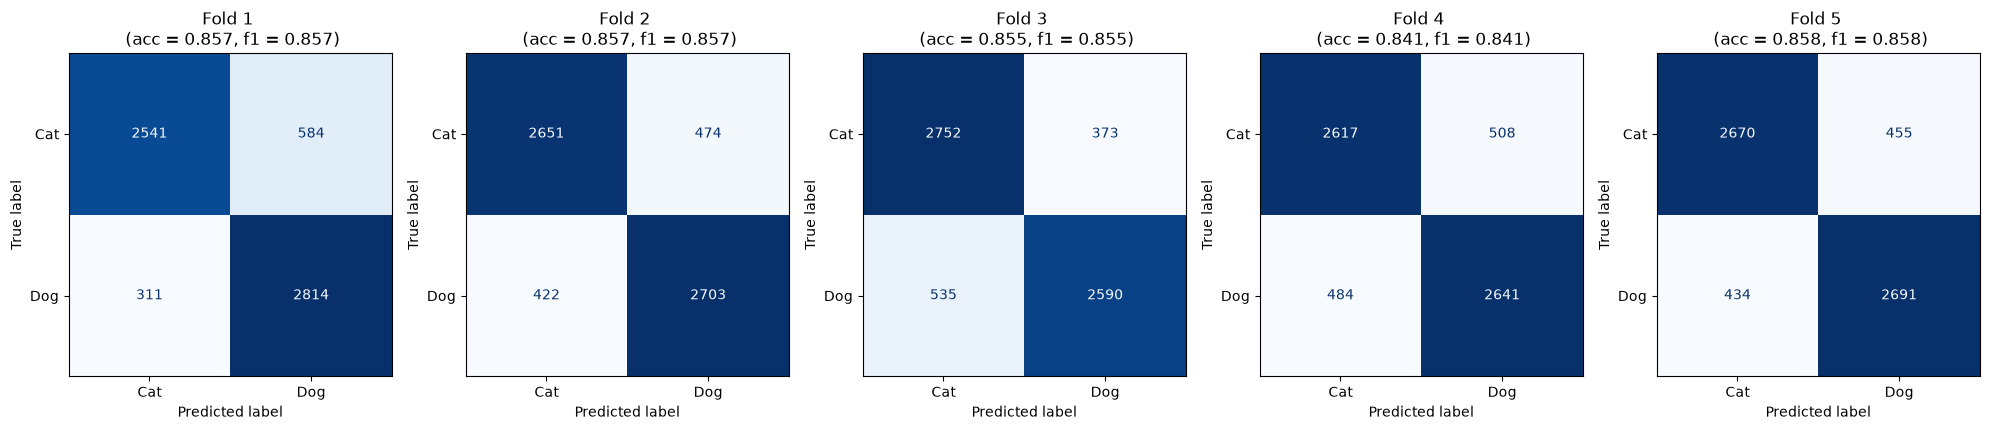

In [4]:
# summarize metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(ncols=N_FOLDS, figsize=(20, 4))
for fold_index in range(N_FOLDS):
    metrics = metrics_by_fold[fold_index]
    acc = metrics["accuracy"]
    f1s = metrics["f1-score"]
    cfm = metrics["confusion-matrix"]
    cmd = ConfusionMatrixDisplay(cfm, display_labels=data_source.classes)
    cmd.plot(ax=axes[fold_index], cmap=plt.cm.Blues, colorbar=False)
    axes[fold_index].set_title(f"Fold {fold_index + 1} \n (acc = {acc:.3f}, f1 = {f1s:.3f})")

plt.tight_layout()
plt.savefig(f"images/{model.name}_test_results.png")